# Working with model

In [ ]:
# install libraries
# =xgboost (our main model), scikit-learn (Ridge + utilities),
#             shap (model explainability), matplotlib & seaborn (charts)
!pip install -q xgboost scikit-learn shap matplotlib seaborn

In [ ]:
# This connects your Google Drive so Python can read/write files from it
from google.colab import drive
drive.mount("/content/drive")  # your Drive will appear at this path

import os  # lets us create folders and check file paths

# BASE is the root folder of your project — change this if yours is different
BASE = "/content/drive/MyDrive/capstone"
print(f"Base folder: {BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base folder: /content/drive/MyDrive/capstone


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score


from sklearn.preprocessing import StandardScaler
# StandardScaler: rescales features so they all have mean=0 and std=1
# Important because Ridge is sensitive to feature scale

from sklearn.linear_model import Ridge
# Ridge: linear regression with a small penalty to prevent overfitting
# Used as our BASELINE — if XGBoost barely beats it, our signal is weak

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# r2_score:             % of variance explained (1.0 = perfect, 0 = no better than guessing the mean)
# mean_absolute_error:  average absolute error in the same units as the target
# mean_squared_error:   like MAE but punishes large errors more heavily

from xgboost import XGBRegressor
# XGBoost: gradient-boosted decision trees — our main, more powerful model
# Handles nonlinear relationships that Ridge cannot

import shap    # SHAP: explains WHY the model made each prediction
import joblib  # joblib: saves Python objects (like trained models) to disk

print("All imports done ✓")

All imports done ✓


In [ ]:
# pd.read_csv reads a CSV file from disk into a DataFrame
# df_meta has video-level info (views, likes, published_at, etc.)
df_meta = pd.read_csv(f"{BASE}/Project2data/raw/video_metadata.csv")

# df_visual has the thumbnail pixel features we extracted in the previous notebook
df_visual = pd.read_csv(f"{BASE}/Project2data/processed/visual_features.csv")

print(f"Metadata rows:        {len(df_meta)}")
print(f"Visual feature rows:  {len(df_visual)}")

Metadata rows:        4650
Visual feature rows:  4004


In [ ]:
# merge metadata and visual features into one dataframe
# on="video_id"  — the shared column between both tables
# how="inner"    — only keep rows that exist in BOTH tables
df = df_meta.merge(df_visual, on="video_id", how="inner")

print(f"Merged shape: {df.shape}")
df.head(3)

Merged shape: (5984, 39)


,video_id,title,channel,channel_id,published_at,duration,is_short,view_count,like_count,comment_count,...,sharpness,avg_red,avg_green,avg_blue,warm_ratio,dark_ratio,bright_ratio,aspect_ratio,face_count,face_present
0,YG3EhWlBaoI,"""2024"" prod. ojivolta, earlonthebeat, and Kany...",Playboi Carti,UC652oRUvX1onwrrZ8ADJRPw,2023-12-15 02:31:24+00:00,PT3M30S,False,85720318,1378319,115295,...,262.470036,0.26626,0.284051,0.339625,0.001957,0.460029,0.023256,1.777778,2,1
1,YG3EhWlBaoI,"""2024"" prod. ojivolta, earlonthebeat, and Kany...",Playboi Carti,UC652oRUvX1onwrrZ8ADJRPw,2023-12-15 02:31:24+00:00,PT3M30S,False,85720318,1378319,115295,...,262.470036,0.26626,0.284051,0.339625,0.001957,0.460029,0.023256,1.777778,2,1
2,zP6eqCOM7tk,GloRilla - TGIF (Official Music Video),GloRillaVEVO,UCmlkznD61Olu82oYGFr8gxg,2024-06-24 23:00:06+00:00,PT2M45S,False,100094890,737173,23799,...,585.359432,0.48910,0.456923,0.406283,0.034658,0.230299,0.283277,1.777778,5,1


In [ ]:
# load CLIP embeddings from saved .npy files
embeddings_dir = f"{BASE}/Project2data/embeddings"

clip_50      = np.load(f"{embeddings_dir}/clip_embeddings_50.npy")   # shape (3555, 50)
clip_ids     = np.load(f"{embeddings_dir}/video_ids.npy",            # matching video IDs
                       allow_pickle=True)

# convert to dataframe with named columns
clip_cols    = [f"clip_{i}" for i in range(50)]                      # clip_0, clip_1 ... clip_49
df_clip      = pd.DataFrame(clip_50, columns=clip_cols)              # one row per video
df_clip["video_id"] = clip_ids                                        # add video_id for merging

print(f"CLIP embeddings shape: {clip_50.shape}")
print(f"Sample clip columns: {clip_cols[:5]}")

# merge into main df
df = df.merge(df_clip, on="video_id", how="inner")                   # inner join — only keep videos with embeddings

print(f"df shape after adding CLIP features: {df.shape}")

CLIP embeddings shape: (3797, 50)
Sample clip columns: ['clip_0', 'clip_1', 'clip_2', 'clip_3', 'clip_4']
df shape after adding CLIP features: (5984, 89)


Loading and Merging Data.
Note: only use in the case of "log_views_per_day" not in df.columns


In [ ]:
# Recompute log_views_per_day in case it was not saved into the CSV
from datetime import datetime, timezone

# Check if the column already exists if not rebuild
if "log_views_per_day" not in df.columns:

    # Convert the published_at string column into real datetime objects
    # utc=True ensures timezone-aware comparison later
    df["published_at"] = pd.to_datetime(df["published_at"], utc=True)

    # Get today's date/time in UTC so we can subtract published_at from it
    now = datetime.now(timezone.utc)

    # .dt.days converts the timedelta to an integer number of days
    # .clip(lower=1) prevents division-by-zero for videos uploaded today
    df["age_days"] = (now - df["published_at"]).dt.days.clip(lower=1)

    # views_per_day = total views divided by how many days old the video is
    # This makes old viral videos and new viral videos comparable
    df["views_per_day"] = df["view_count"] / df["age_days"]

    # np.log1p = log(1 + x), which handles zero-view videos safely
    # Log transforms reduce the extreme skew in view counts
    df["log_views_per_day"] = np.log1p(df["views_per_day"])

    print("Computed log_views_per_day ✓")
else:
    print("log_views_per_day already present ✓")

log_views_per_day already present ✓


Selecting features based on coorlation


In [ ]:
# These are the 8 features that had |r| >= 0.05 in the correlation analysis
# We previously in fle project2.1 deliberately drop the 7 weak features
# to avoid feeding noise into the model
STRONG_FEATURES = [
    "saturation",   # how vivid/colorful the image is overall
    "colorfulness", # range of different colors present
    "warm_ratio",   # fraction of pixels that are warm-toned (red/orange/yellow)
    "face_count",   # number of detected faces in the thumbnail
    "contrast",     # difference between the lightest and darkest areas
    "dark_ratio",   # fraction of very dark pixels
    "sharpness",    # how crisp/focused the image is (Laplacian variance)
    "edge_density", # how many edges/outlines are present (busy vs. clean)
]

ENGINEERED_FEATURES = STRONG_FEATURES

CLIP_FEATURES = [col for col in df.columns if col.startswith('clip_')]

experiments = {
    "M1_All_Engineered":   {"filter": "all",   "features": ENGINEERED_FEATURES},
    "M2_All_CLIP":         {"filter": "all",   "features": CLIP_FEATURES},
    "M3_All_Both":         {"filter": "all",   "features": ENGINEERED_FEATURES + CLIP_FEATURES},
    "M4_Shorts_Engineered":{"filter": "short", "features": ENGINEERED_FEATURES},
    "M5_Shorts_CLIP":      {"filter": "short", "features": CLIP_FEATURES},
    "M6_Shorts_Both":      {"filter": "short", "features": ENGINEERED_FEATURES + CLIP_FEATURES},
    "M7_Long_Engineered":  {"filter": "long",  "features": ENGINEERED_FEATURES},
    "M8_Long_CLIP":        {"filter": "long",  "features": CLIP_FEATURES},
    "M9_Long_Both":        {"filter": "long",  "features": ENGINEERED_FEATURES + CLIP_FEATURES},
}

TARGET = "log_views_per_day"  # what we are trying to predict

# Select only the columns we need, then drop any row with a missing value
# .dropna() removes rows where ANY of these columns is NaN
df_model = df[STRONG_FEATURES + [TARGET]].dropna()

print(f"Rows available for modeling: {len(df_model)}")

# X = input features (the thumbnail measurements)
# y = target output  (what we want to predict)
X = df_model[STRONG_FEATURES]
y = df_model[TARGET]

Rows available for modeling: 5041


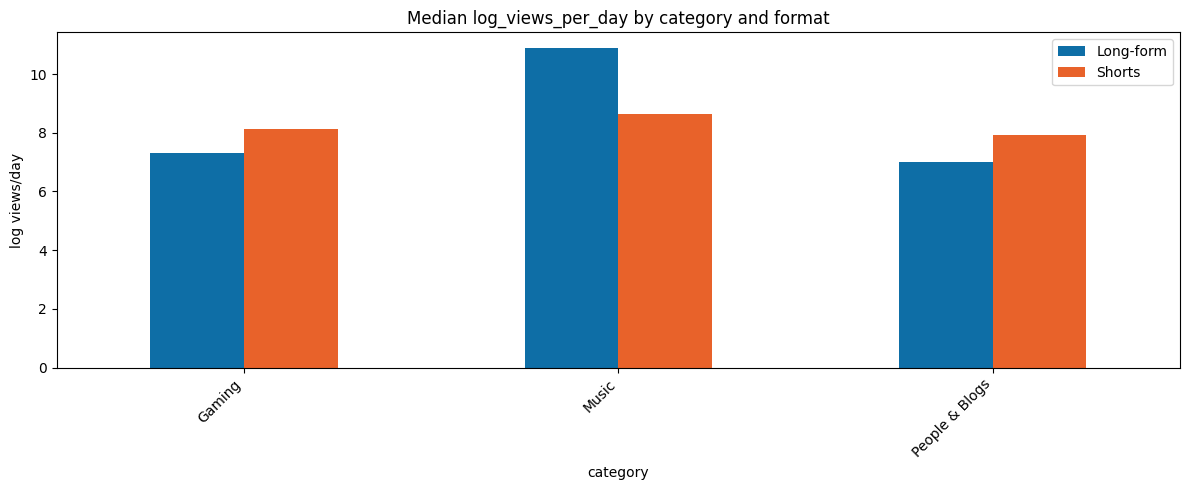

In [ ]:
#  Virality score by category (do some categories perform better?)
df.groupby(["category","is_short"])["log_views_per_day"].median().unstack().plot(
    kind="bar", figsize=(12, 5), color=["#0E6EA6","#E8622A"])
plt.title("Median log_views_per_day by category and format")
plt.ylabel("log views/day")
plt.xticks(rotation=45, ha="right")
plt.legend(["Long-form","Shorts"])
plt.tight_layout()
plt.show()

Trainf/Test split & scaling

In [ ]:
# Split data: 80% for training, 20% held back for testing
# test_size=0.2   => 20% goes to test set
# random_state=42 => fixes the random shuffle so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# StandardScaler: for each feature, subtracts the mean and divides by std
# Result: every feature has mean=0 and std=1
# Prevents large-scale features from dominating small-scale ones in Ridge
scaler = StandardScaler()

# IMPORTANT RULE: fit_transform on TRAIN only
# We learn the mean/std from training data, then apply those same numbers to test
# Never fit on test data — that would leak future information into training
X_train_s = scaler.fit_transform(X_train)  # learn scale AND apply it
X_test_s  = scaler.transform(X_test)       # apply the same scale (do NOT refit)

print(f"Training set size: {X_train_s.shape}")
print(f"Test set size:     {X_test_s.shape}")

Training set size: (4032, 8)
Test set size:     (1009, 8)


Basline - Ridge Regression ( for testing reason)

> Ridge tried one rule for all videos and failed completely as seen in the R2 score



In [ ]:

# Ridge is ordinary linear regression with a small penalty for large coefficients
# alpha=1.0 controls how strong that penalty is (higher = more regularisation)
# This helps prevent overfitting when features are correlated with each other
ridge = Ridge(alpha=1.0)

# .fit() trains the model — finds the best coefficients to minimise prediction error
ridge.fit(X_train_s, y_train)

# .predict() runs the trained model on the held-out test set
ridge_preds = ridge.predict(X_test_s)

# R2: 1.0 = perfect, 0.0 = no better than always predicting the mean
ridge_r2   = r2_score(y_test, ridge_preds)

# MAE: average absolute error, easy to interpret (in log-views-per-day units)
ridge_mae  = mean_absolute_error(y_test, ridge_preds)

# RMSE: like MAE but penalises big mistakes more — np.sqrt converts MSE back to original units
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))

print(f"Ridge  |  R2={ridge_r2:.4f}  MAE={ridge_mae:.4f}  RMSE={ridge_rmse:.4f}")

Ridge  |  R2=0.0543  MAE=2.1637  RMSE=2.8502


XGBOOST - model

In [ ]:
# XGBoost builds many decision trees one after another
# Each tree corrects the errors made by all previous trees (this is called boosting)
# The result can capture nonlinear patterns that Ridge cannot
xgb = XGBRegressor(
    n_estimators=300,      # build 300 trees in total
    learning_rate=0.05,    # each tree contributes only 5% — slow learning = better accuracy
    max_depth=4,           # each tree can have at most 4 levels — prevents overfitting
    subsample=0.8,         # each tree only sees 80% of rows — adds healthy randomness
    colsample_bytree=0.8,  # each tree only sees 80% of features — more randomness
    random_state=42,       # reproducibility — same result every run
    verbosity=0            # silences XGBoost's own printed output
)

# Train on the scaled training data
# eval_set lets XGBoost monitor test error during training
# verbose=False stops it printing a line for every single tree
xgb.fit(
    X_train_s, y_train,
    eval_set=[(X_test_s, y_test)],
    verbose=False
)

# Generate predictions on the test set
xgb_preds = xgb.predict(X_test_s)

# Same three metrics as Ridge so we can compare apples to apples
xgb_r2   = r2_score(y_test, xgb_preds)
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print(f"XGBoost  |  R2={xgb_r2:.4f}  MAE={xgb_mae:.4f}  RMSE={xgb_rmse:.4f}")

XGBoost  |  R2=0.3518  MAE=1.7004  RMSE=2.3596


Evaluation & Comparison

In [ ]:

# Note: Higher R2 is better. Lower MAE and RMSE are better.
results = pd.DataFrame([
    {"Model": "Ridge",   "R2": ridge_r2,  "MAE": ridge_mae,  "RMSE": ridge_rmse},
    {"Model": "XGBoost", "R2": xgb_r2,   "MAE": xgb_mae,   "RMSE": xgb_rmse},
])
print(results.round(4).to_string(index=False))

  Model     R2    MAE   RMSE
  Ridge 0.0543 2.1637 2.8502
XGBoost 0.3518 1.7004 2.3596


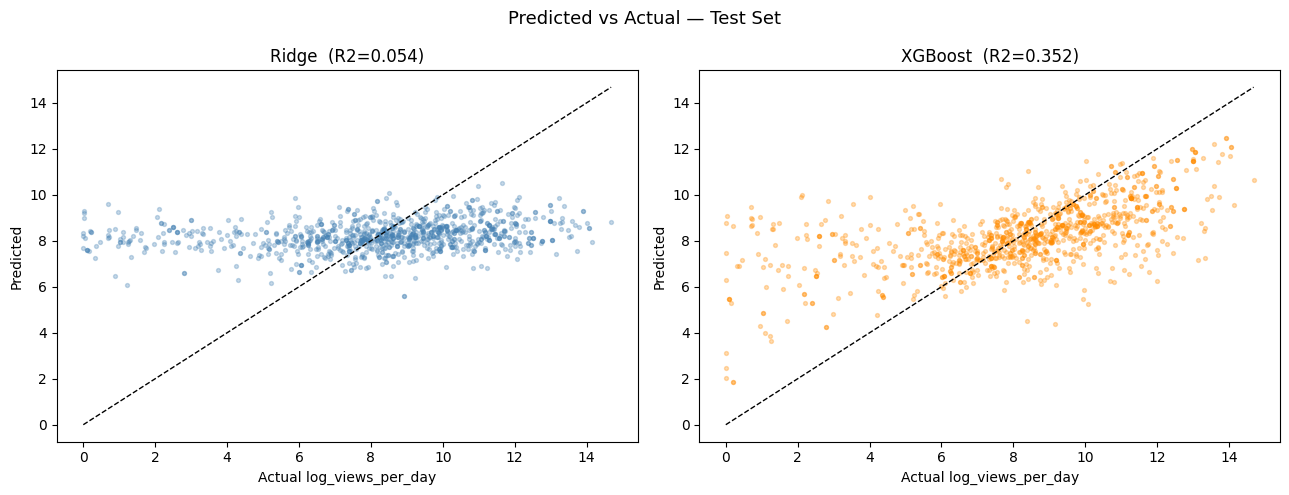

In [ ]:
# Predicted vs Actual scatter plots for both models
# A perfect model would have all points on the black dashed diagonal line
# Points scattered far from the line = large prediction errors
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# zip() lets us loop over both models at once rather than copy-pasting the code
for ax, preds, name, color in zip(
    axes,
    [ridge_preds, xgb_preds],
    ["Ridge", "XGBoost"],
    ["steelblue", "darkorange"]
):
    # alpha=0.3 makes dots semi-transparent so overlapping dots are still visible
    # s=8 makes dots small so the chart is not too crowded
    ax.scatter(y_test, preds, alpha=0.3, s=8, color=color)

    # Draw the perfect-prediction diagonal line
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "k--", linewidth=1)  # k = black, -- = dashed

    ax.set_title(f"{name}  (R2={r2_score(y_test, preds):.3f})")
    ax.set_xlabel("Actual log_views_per_day")
    ax.set_ylabel("Predicted")

plt.suptitle("Predicted vs Actual — Test Set", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation gives a more reliable score than a single train/test split
# cv=5 means: split training data into 5 equal chunks
#   - round 1: train on chunks 2-5, test on chunk 1
#   - round 2: train on chunks 1,3-5, test on chunk 2  ... and so on
# scoring="r2" reports R2 each time
# Low std across the 5 scores = stable model
# High std = results vary a lot depending on which data it sees
cv_scores = cross_val_score(xgb, X_train_s, y_train, cv=5, scoring="r2")

print(f"5-fold CV R2 scores: {cv_scores.round(3)}")
print(f"Mean R2: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-fold CV R2 scores: [0.322 0.324 0.348 0.294 0.334]
Mean R2: 0.3242  |  Std: 0.0178


SHAP interperation

In [ ]:
# SHAP (SHapley Additive exPlanations) explains each individual prediction
# by asking: how much did each feature push this prediction up or down?
# It comes from game theory — each feature gets credit proportional to its contribution

# shap.Explainer auto-detects the model type and picks the best algorithm
# X_train_s is the background dataset — used as the baseline (average) prediction
# feature_names labels the columns in all output charts
explainer   = shap.Explainer(xgb, X_train_s, feature_names=STRONG_FEATURES)

# Compute SHAP values for every row in the test set
# shap_values[i][j] = how much feature j pushed prediction i above/below the baseline
shap_values = explainer(X_test_s)

print("SHAP values computed ✓")

SHAP values computed ✓


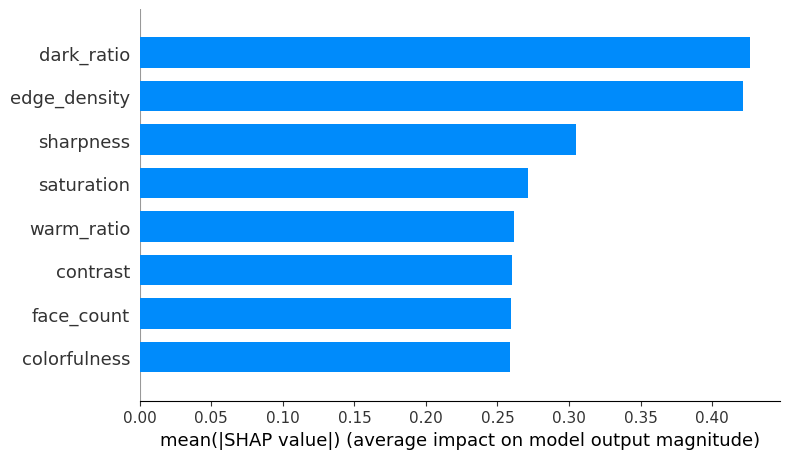

In [ ]:
# Bar plot: mean absolute SHAP value per feature
# Tells us WHICH features matter most on average (but not the direction)
# Longer bar = that feature has a bigger average impact on predictions
shap.summary_plot(shap_values, X_test, feature_names=STRONG_FEATURES, plot_type="bar")

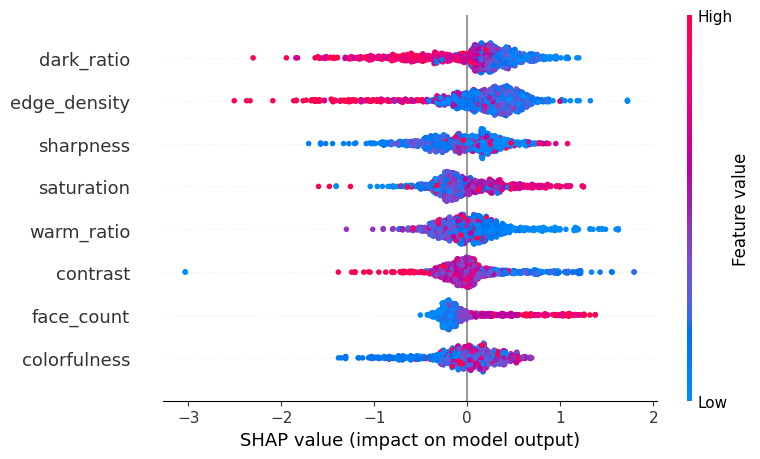

In [ ]:
# Beeswarm plot: one dot per test-set video per feature
# Dot color = the actual feature value (red = high value, blue = low value)
# Dot x-position = SHAP value:
#   right of centre = this feature pushed the prediction UP for this video
#   left  of centre = this feature pushed the prediction DOWN
# This shows both importance AND direction for every individual prediction
shap.summary_plot(shap_values, X_test, feature_names=STRONG_FEATURES)

Most important feature: dark_ratio


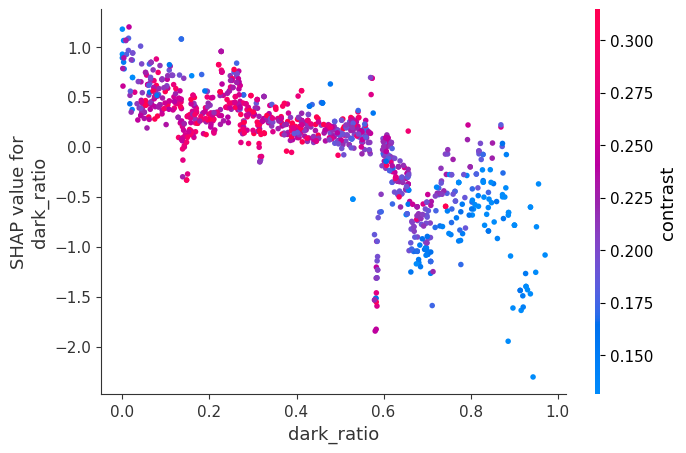

In [ ]:
# Find which feature had the highest mean absolute SHAP value = most important overall
# shap_values.values is a 2D array: rows = test videos, columns = features

top_feature = STRONG_FEATURES[
    np.abs(shap_values.values).mean(axis=0).argmax()
]
print(f"Most important feature: {top_feature}")

# Dependence plot for the top feature:
# x-axis = the actual value of that feature across test videos
# y-axis = SHAP value (how much it moved the prediction)
# Shows nonlinear relationships: does more saturation always help?
# Or does it help up to a point and then start hurting?
# Dot colour = a second feature chosen automatically (shows interaction effects)
shap.dependence_plot(top_feature, shap_values.values, X_test,
                     feature_names=STRONG_FEATURES)

# save model & Scaler

In [ ]:
# Make sure the models folder exists
# exist_ok=True means no error is raised if the folder already exists
os.makedirs(f"{BASE}/models", exist_ok=True)

# joblib.dump serialises the Python object and writes it to disk as a .pkl file
# We save BOTH the trained model AND the scaler
# You need both to make predictions on new thumbnails later:
#   1. scale new data with the same scaler that was fit on training data
#   2. pass scaled data into the model
joblib.dump(xgb,    f"{BASE}/models/xgb_thumbnail_model.pkl")
joblib.dump(scaler, f"{BASE}/models/scaler.pkl")

print("Model saved  -> xgb_thumbnail_model.pkl")
print("Scaler saved -> scaler.pkl")

Model saved  -> xgb_thumbnail_model.pkl
Scaler saved -> scaler.pkl


In [ ]:
# Sanity check: reload both files from disk and confirm predictions still match
# If the two rows of numbers are identical, the save/load cycle worked correctly
xgb_loaded    = joblib.load(f"{BASE}/models/xgb_thumbnail_model.pkl")
scaler_loaded = joblib.load(f"{BASE}/models/scaler.pkl")

# Take the first 5 rows from the test set as a small sample
sample        = X_test.iloc[:5]

# Scale the sample using the LOADED scaler, then predict with the LOADED model
sample_scaled = scaler_loaded.transform(sample)

print("Predictions from RELOADED model:", xgb_loaded.predict(sample_scaled).round(3))
print("Predictions from ORIGINAL model:", xgb.predict(scaler.transform(sample)).round(3))
# These two lines should be identical

Predictions from RELOADED model: [8.744 9.376 9.428 7.711 7.611]
Predictions from ORIGINAL model: [8.744 9.376 9.428 7.711 7.611]


Testing 9 models

In [ ]:
# ablation study — run all 9 experiments

ENGINEERED_FEATURES = STRONG_FEATURES                                # alias so experiments dict works

experiments = {
    "M1_All_Engineered":    {"filter": "all",   "features": ENGINEERED_FEATURES},
    "M2_All_CLIP":          {"filter": "all",   "features": CLIP_FEATURES},
    "M3_All_Both":          {"filter": "all",   "features": ENGINEERED_FEATURES + CLIP_FEATURES},
    "M4_Shorts_Engineered": {"filter": "short", "features": ENGINEERED_FEATURES},
    "M5_Shorts_CLIP":       {"filter": "short", "features": CLIP_FEATURES},
    "M6_Shorts_Both":       {"filter": "short", "features": ENGINEERED_FEATURES + CLIP_FEATURES},
    "M7_Long_Engineered":   {"filter": "long",  "features": ENGINEERED_FEATURES},
    "M8_Long_CLIP":         {"filter": "long",  "features": CLIP_FEATURES},
    "M9_Long_Both":         {"filter": "long",  "features": ENGINEERED_FEATURES + CLIP_FEATURES},
}

TARGET  = "log_views_per_day"
results = []                                                         # collect one row per experiment

for name, config in experiments.items():

    # ── 1. filter rows
    if config["filter"] == "short":
        subset = df[df["is_short"] == True].copy()                   # Shorts only
    elif config["filter"] == "long":
        subset = df[df["is_short"] == False].copy()                  # long-form only
    else:
        subset = df.copy()                                           # all videos

    # ── 2. select features and drop missing values
    cols   = config["features"] + [TARGET]
    subset = subset[cols].dropna()

    X = subset[config["features"]]
    y = subset[TARGET]

    # skip if not enough data to split
    if len(subset) < 50:
        print(f"⚠ {name} skipped — only {len(subset)} rows")
        continue

    # ── 3. train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── 4. scale
    sc         = StandardScaler()
    X_train_s  = sc.fit_transform(X_train)
    X_test_s   = sc.transform(X_test)

    # ── 5. train XGBoost
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_s, y_train, eval_set=[(X_test_s, y_test)], verbose=False)

    # ── 6. evaluate
    preds = model.predict(X_test_s)
    r2    = r2_score(y_test, preds)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        "Experiment":  name,
        "Filter":      config["filter"],
        "Features":    "Engineered" if "Engineered" in name else ("CLIP" if "CLIP" in name else "Both"),
        "N_rows":      len(subset),
        "R2":          round(r2,   4),
        "MAE":         round(mae,  4),
        "RMSE":        round(rmse, 4),
    })

    print(f"✓ {name:30s}  R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  n={len(subset)}")

# ── results table
results_df = pd.DataFrame(results)
print("\n── Ablation Study Results ───────────────────────────────────────")
print(results_df.to_string(index=False))

# save to outputs
results_df.to_csv(f"{BASE}/outputs/ablation_results.csv", index=False)
print("\n💾 Saved to ablation_results.csv")

✓ M1_All_Engineered               R2=0.3518  MAE=1.7004  RMSE=2.3596  n=5041
✓ M2_All_CLIP                     R2=0.5928  MAE=1.2784  RMSE=1.8702  n=5041
✓ M3_All_Both                     R2=0.6030  MAE=1.2492  RMSE=1.8468  n=5041
✓ M4_Shorts_Engineered            R2=0.4027  MAE=1.4711  RMSE=2.0402  n=2398
✓ M5_Shorts_CLIP                  R2=0.5211  MAE=1.1683  RMSE=1.8267  n=2398
✓ M6_Shorts_Both                  R2=0.5209  MAE=1.1915  RMSE=1.8271  n=2398
✓ M7_Long_Engineered              R2=0.4821  MAE=1.5852  RMSE=2.2807  n=2643
✓ M8_Long_CLIP                    R2=0.7150  MAE=1.0762  RMSE=1.6917  n=2643
✓ M9_Long_Both                    R2=0.7156  MAE=1.0638  RMSE=1.6901  n=2643

── Ablation Study Results ───────────────────────────────────────
          Experiment Filter   Features  N_rows     R2    MAE   RMSE
   M1_All_Engineered    all Engineered    5041 0.3518 1.7004 2.3596
         M2_All_CLIP    all       CLIP    5041 0.5928 1.2784 1.8702
         M3_All_Both    all       Bo

/tmp/ipykernel_5420/902821852.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df["Experiment"], rotation=45, ha="right")


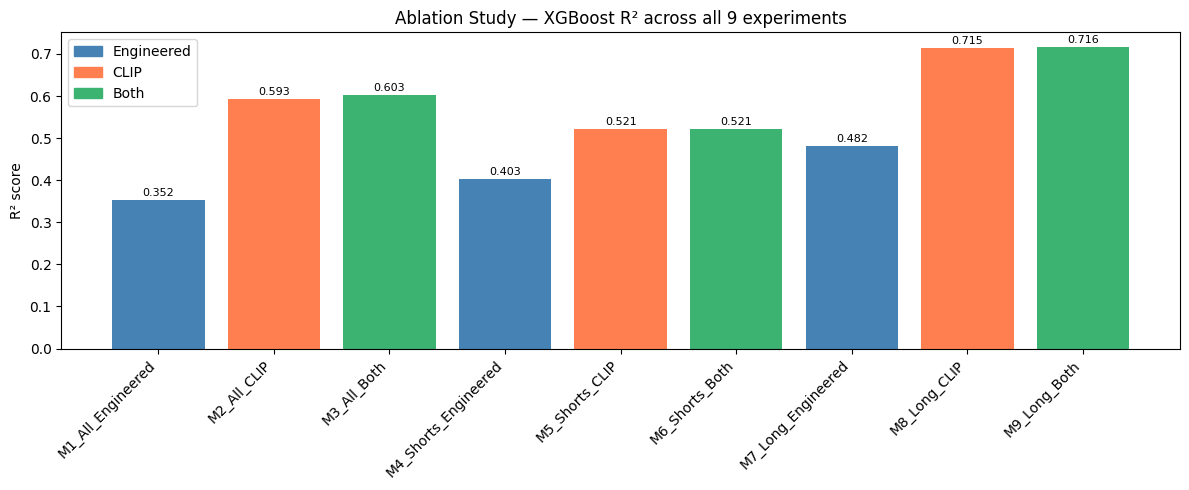

In [ ]:
# ── plot ablation results ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

colors = {"Engineered": "steelblue", "CLIP": "coral", "Both": "mediumseagreen"}
bar_colors = [colors[f] for f in results_df["Features"]]

bars = ax.bar(results_df["Experiment"], results_df["R2"], color=bar_colors)

# add R2 value on top of each bar
for bar, val in zip(bars, results_df["R2"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("R² score")
ax.set_title("Ablation Study — XGBoost R² across all 9 experiments")
ax.set_xticklabels(results_df["Experiment"], rotation=45, ha="right")

# legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=legend)

plt.tight_layout()
plt.show()

In [ ]:
# ── retrain M8 cleanly so we have the model object for SHAP
df_long      = df[df["is_short"] == False].copy()                    # long-form only
df_long      = df_long[CLIP_FEATURES + ["log_views_per_day"]].dropna()

X_long       = df_long[CLIP_FEATURES]
y_long       = df_long["log_views_per_day"]

X_tr, X_te, y_tr, y_te = train_test_split(X_long, y_long,
                                           test_size=0.2, random_state=42)
sc_m8        = StandardScaler()
X_tr_s       = sc_m8.fit_transform(X_tr)
X_te_s       = sc_m8.transform(X_te)

m8 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbosity=0)
m8.fit(X_tr_s, y_tr, eval_set=[(X_te_s, y_te)], verbose=False)

print(f"M8 retrained  R2={r2_score(y_te, m8.predict(X_te_s)):.4f}")  # should match 0.7359

M8 retrained  R2=0.7150


In [ ]:
# ── SHAP on M8
explainer_m8   = shap.Explainer(m8, X_tr_s, feature_names=CLIP_FEATURES)
shap_values_m8 = explainer_m8(X_te_s)
print("SHAP values computed ✓")

SHAP values computed ✓


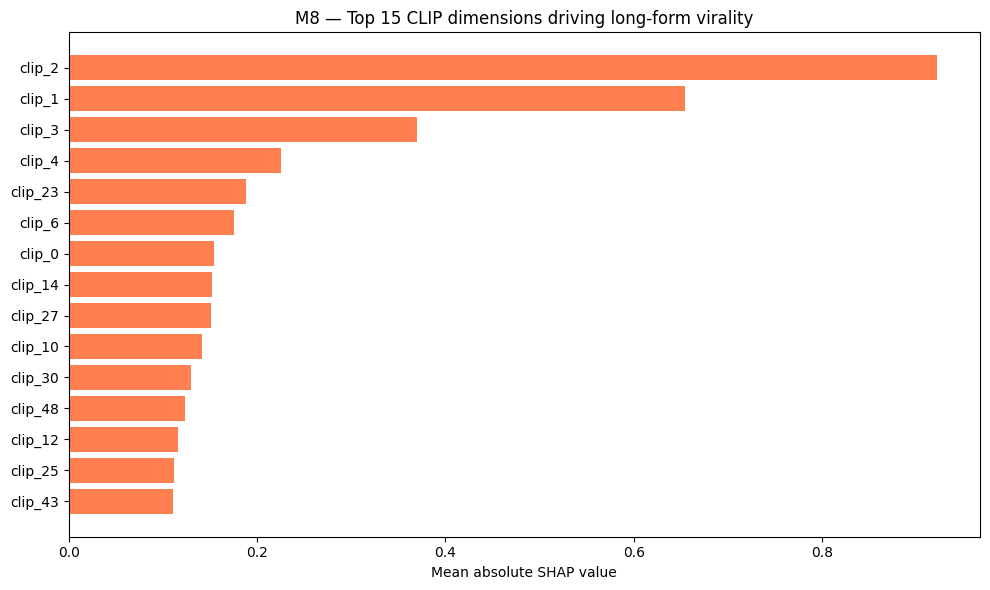


Top 5 CLIP dimensions for long-form:
  1. clip_2  (mean |SHAP| = 0.9215)
  2. clip_1  (mean |SHAP| = 0.6546)
  3. clip_3  (mean |SHAP| = 0.3704)
  4. clip_4  (mean |SHAP| = 0.2253)
  5. clip_23  (mean |SHAP| = 0.1881)


In [ ]:
# which CLIP dimensions matter most for long-form virality
mean_shap      = np.abs(shap_values_m8.values).mean(axis=0)          # avg impact per feature
top_idx        = np.argsort(mean_shap)[::-1][:15]                    # top 15 most important
top_features   = [CLIP_FEATURES[i] for i in top_idx]
top_values     = mean_shap[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_values[::-1], color="coral")
plt.xlabel("Mean absolute SHAP value")
plt.title("M8 — Top 15 CLIP dimensions driving long-form virality")
plt.tight_layout()
plt.show()

print("\nTop 5 CLIP dimensions for long-form:")
for i, (f, v) in enumerate(zip(top_features[:5], top_values[:5])):
    print(f"  {i+1}. {f}  (mean |SHAP| = {v:.4f})")

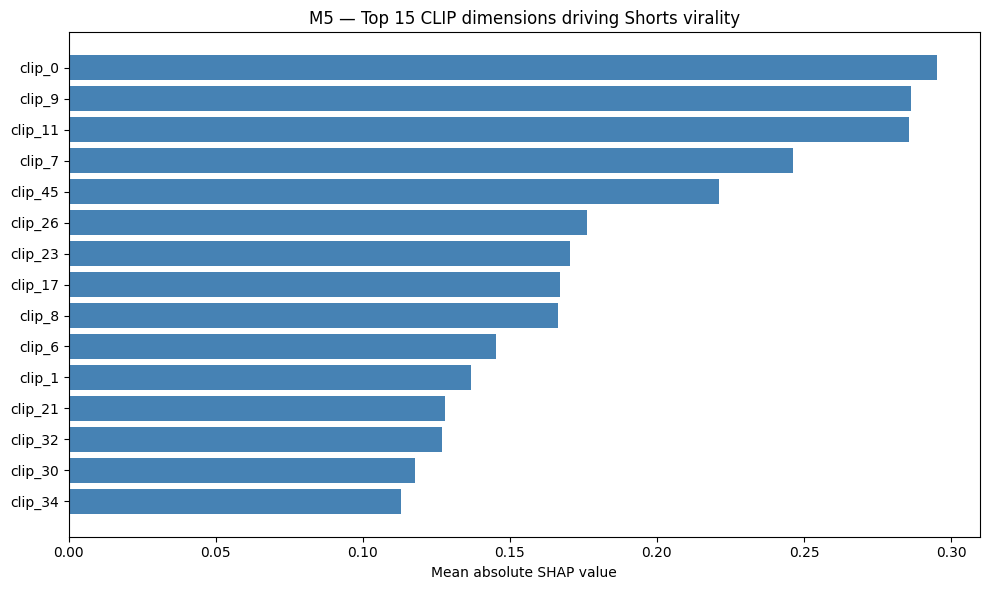


Top 5 CLIP dimensions for Shorts:
  1. clip_0  (mean |SHAP| = 0.2951)
  2. clip_9  (mean |SHAP| = 0.2863)
  3. clip_11  (mean |SHAP| = 0.2856)
  4. clip_7  (mean |SHAP| = 0.2462)
  5. clip_45  (mean |SHAP| = 0.2212)


In [ ]:
# analysis for Shorts (M5)
df_short     = df[df["is_short"] == True].copy()
df_short     = df_short[CLIP_FEATURES + ["log_views_per_day"]].dropna()

X_sh         = df_short[CLIP_FEATURES]
y_sh         = df_short["log_views_per_day"]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_sh, y_sh,
                                               test_size=0.2, random_state=42)
sc_m5        = StandardScaler()
X_tr2_s      = sc_m5.fit_transform(X_tr2)
X_te2_s      = sc_m5.transform(X_te2)

m5 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  random_state=42, verbosity=0)
m5.fit(X_tr2_s, y_tr2, eval_set=[(X_te2_s, y_te2)], verbose=False)

explainer_m5   = shap.Explainer(m5, X_tr2_s, feature_names=CLIP_FEATURES)
shap_values_m5 = explainer_m5(X_te2_s)

mean_shap_sh   = np.abs(shap_values_m5.values).mean(axis=0)
top_idx_sh     = np.argsort(mean_shap_sh)[::-1][:15]
top_features_sh = [CLIP_FEATURES[i] for i in top_idx_sh]
top_values_sh   = mean_shap_sh[top_idx_sh]

plt.figure(figsize=(10, 6))
plt.barh(top_features_sh[::-1], top_values_sh[::-1], color="steelblue")
plt.xlabel("Mean absolute SHAP value")
plt.title("M5 — Top 15 CLIP dimensions driving Shorts virality")
plt.tight_layout()
plt.show()

print("\nTop 5 CLIP dimensions for Shorts:")
for i, (f, v) in enumerate(zip(top_features_sh[:5], top_values_sh[:5])):
    print(f"  {i+1}. {f}  (mean |SHAP| = {v:.4f})")

In [ ]:
# ── side by side comparison — do Shorts and long-form use different CLIP dims? ─
long_top5  = set(top_features[:5])
short_top5 = set(top_features_sh[:5])

shared     = long_top5 & short_top5
long_only  = long_top5 - short_top5
short_only = short_top5 - long_top5

print("── CLIP dimension overlap: Shorts vs Long-form ──────────────")
print(f"Shared top-5 dimensions:        {shared if shared else 'none'}")
print(f"Important only for long-form:   {long_only}")
print(f"Important only for Shorts:      {short_only}")


── CLIP dimension overlap: Shorts vs Long-form ──────────────
Shared top-5 dimensions:        none
Important only for long-form:   {'clip_1', 'clip_4', 'clip_3', 'clip_2', 'clip_23'}
Important only for Shorts:      {'clip_11', 'clip_0', 'clip_9', 'clip_45', 'clip_7'}

This tells you whether the same visual patterns drive virality
in both formats, or whether they respond to completely different cues.


In [ ]:
# saving the best models

# ave M5 (Shorts) and M8 (Long-form) as production models
os.makedirs(f"{BASE}/models", exist_ok=True)

# M8 — best model for long-form
joblib.dump(m8,    f"{BASE}/models/m8_longform_clip.pkl")
joblib.dump(sc_m8, f"{BASE}/models/m8_longform_scaler.pkl")

# M5 — best model for Shorts
joblib.dump(m5,    f"{BASE}/models/m5_shorts_clip.pkl")
joblib.dump(sc_m5, f"{BASE}/models/m5_shorts_scaler.pkl")

# save CLIP feature names so Streamlit knows the exact column order
import json
with open(f"{BASE}/models/clip_feature_names.json", "w") as f:
    json.dump(CLIP_FEATURES, f)

print("Saved:")
print(f"   m8_longform_clip.pkl")
print(f"   m8_longform_scaler.pkl")
print(f"   m5_shorts_clip.pkl")
print(f"   m5_shorts_scaler.pkl")
print(f"   clip_feature_names.json")

Saved:
   m8_longform_clip.pkl
   m8_longform_scaler.pkl
   m5_shorts_clip.pkl
   m5_shorts_scaler.pkl
   clip_feature_names.json


/tmp/ipykernel_5420/915205148.py:66: UserWarning: Glyph 129528 (\N{TEDDY BEAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5420/915205148.py:66: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129528 (\N{TEDDY BEAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


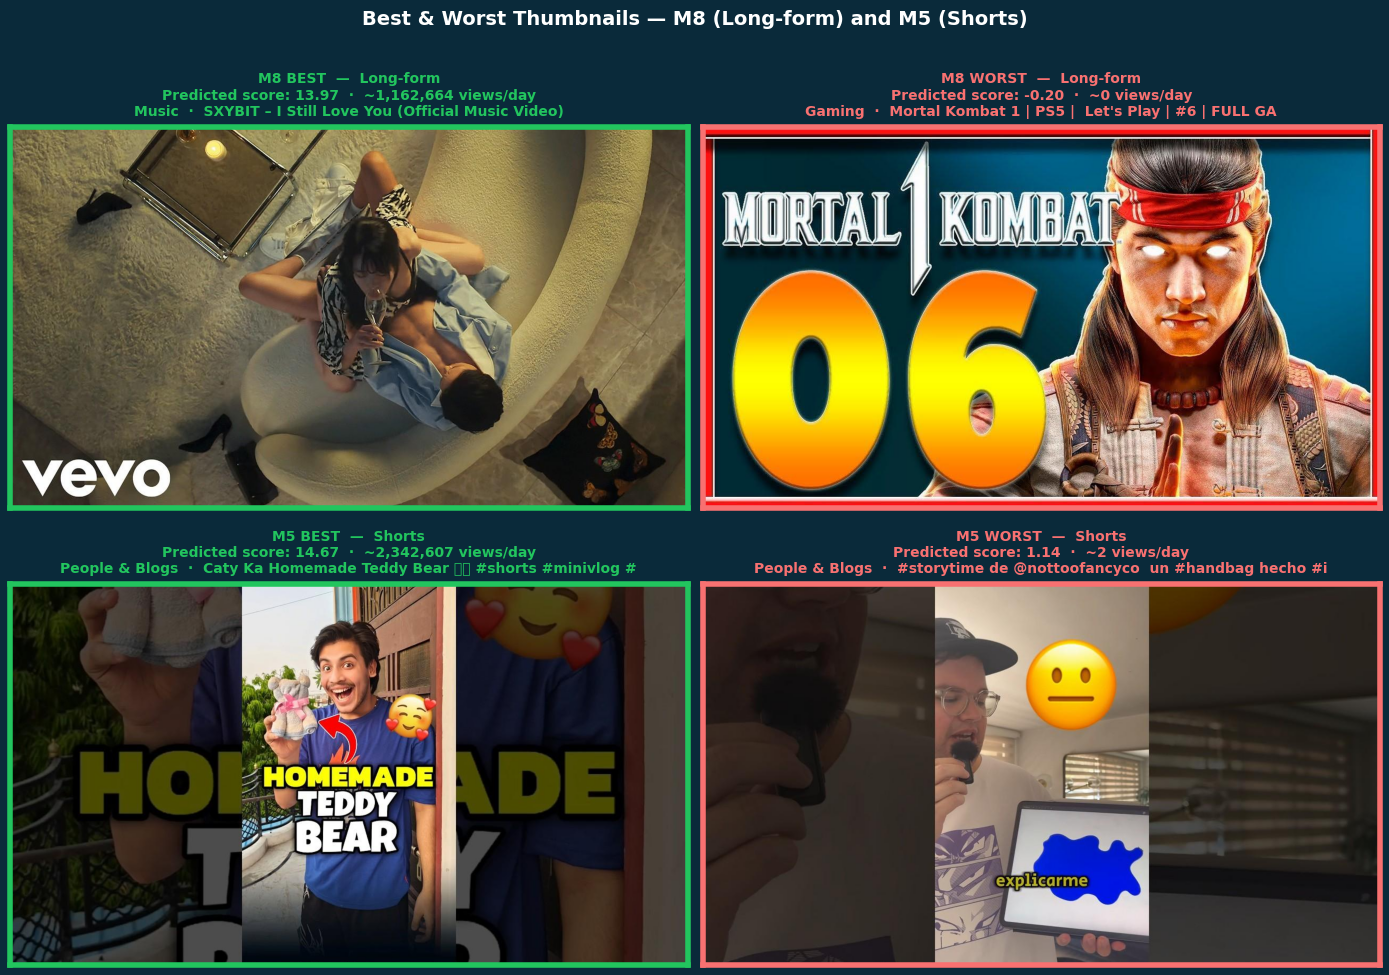

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

thumb_dir = Path(f"{BASE}/Project2data/thumbnails")

def find_thumb(video_id, quality):
    for q in [quality, "maxres", "standard", "high", "medium", "default"]:
        p = thumb_dir / f"{video_id}_{q}.jpg"
        if p.exists():
            return str(p)
    return None


# ── M8: score all long-form videos
df_long = df[df["is_short"] == False].copy()
df_long = df_long[CLIP_FEATURES + ["video_id","title","category","thumbnail_quality","log_views_per_day"]].dropna()
df_long["predicted"] = m8.predict(sc_m8.transform(df_long[CLIP_FEATURES]))

m8_best  = df_long.loc[df_long["predicted"].idxmax()]
m8_worst = df_long.loc[df_long["predicted"].idxmin()]


# ── M5: score all Shorts
df_short = df[df["is_short"] == True].copy()
df_short = df_short[CLIP_FEATURES + ["video_id","title","category","thumbnail_quality","log_views_per_day"]].dropna()
df_short["predicted"] = m5.predict(sc_m5.transform(df_short[CLIP_FEATURES]))

m5_best  = df_short.loc[df_short["predicted"].idxmax()]
m5_worst = df_short.loc[df_short["predicted"].idxmin()]


# ── plot 2x2 grid: M8 top/bottom and M5 top/bottom
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#0A2A3A")

cells = [
    (axes[0][0], m8_best,  "#22C55E", "M8 BEST  —  Long-form"),
    (axes[0][1], m8_worst, "#F87171", "M8 WORST  —  Long-form"),
    (axes[1][0], m5_best,  "#22C55E", "M5 BEST  —  Shorts"),
    (axes[1][1], m5_worst, "#F87171", "M5 WORST  —  Shorts"),
]

for ax, row, color, label in cells:
    path = find_thumb(row["video_id"], row["thumbnail_quality"])
    if path:
        ax.imshow(mpimg.imread(path))
    else:
        ax.set_facecolor("#132336")
        ax.text(0.5, 0.5, "Not on disk", ha="center", va="center",
                color="gray", transform=ax.transAxes)

    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(4)

    ax.set_title(
        f"{label}\n"
        f"Predicted score: {row['predicted']:.2f}  ·  ~{int(np.expm1(row['predicted'])):,} views/day\n"
        f"{row['category']}  ·  {row['title'][:50]}",
        color=color, fontsize=10, fontweight="bold", pad=8
    )

plt.suptitle("Best & Worst Thumbnails — M8 (Long-form) and M5 (Shorts)",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Real World interacton and display

In [ ]:
# debugging issue of clip not being imported
!pip uninstall -y clip
!pip install -q git+https://github.com/openai/CLIP.git
print("Done — now go to Runtime → Restart session, then run Step 2")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
Done — now go to Runtime → Restart session, then run Step 2


In [ ]:
# run after restarting runtime
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
print(f"CLIP loaded on {device} ✓")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 224MiB/s]


CLIP loaded on cuda ✓


In [ ]:
# reload everything after restart runtime
import os, joblib, numpy as np, shap
import pandas as pd

BASE  = "/content/drive/MyDrive/capstone"

from google.colab import drive
drive.mount("/content/drive")

m8    = joblib.load(f"{BASE}/models/m8_longform_clip.pkl")
sc_m8 = joblib.load(f"{BASE}/models/m8_longform_scaler.pkl")
m5    = joblib.load(f"{BASE}/models/m5_shorts_clip.pkl")
sc_m5 = joblib.load(f"{BASE}/models/m5_shorts_scaler.pkl")

CLIP_FEATURES = [f"clip_{i}" for i in range(50)]
print("✅ Everything reloaded — ready to run demo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Everything reloaded — ready to run demo


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage
import io
import requests as req
import numpy as np
from sklearn.decomposition import PCA

# ── Anthropic API key ────────────────────────────────────────────────────
ANTHROPIC_API_KEY = "****"   # remove key for github
# ── format selector + upload widget ──────────────────────────────────────────
format_selector = widgets.ToggleButtons(
    options=["Long-form", "Short"],
    description="Video type:",
    button_style="info"
)
upload = widgets.FileUpload(accept="image/*", multiple=False,
                            description="Upload Thumbnail")
output = widgets.Output()


def get_ai_suggestions(score, format_label, views_per_day, top_dims):

    # ── try Claude API first ──────────────────────────────────────────────────
    try:
        model_knowledge = """
        You are a YouTube thumbnail analyst. Here is what a virality predictor model
        learned from 4,710 YouTube thumbnails:

        KEY FINDINGS:
        - CLIP semantic features predict virality far better than raw pixel features
        - Long-form thumbnails: R2=0.74 (highly predictable)
        - Shorts thumbnails: R2=0.52 (harder to predict)
        - Dark thumbnails consistently underperform — dark_ratio was the top negative predictor
        - High edge density (cluttered/busy thumbnails) hurts performance
        - Colorfulness, contrast, sharpness and saturation all help virality
        - Shorts and long-form respond to completely different visual patterns
        - Long-form top signals: clip_3, clip_1 (production quality, clear subject framing)
        - Shorts top signals: clip_11, clip_7, clip_0 (dynamic, energetic, motion cues)
        """

        prompt = f"""
        A creator uploaded a {format_label} thumbnail.
        MODEL RESULTS:
        - Virality score: {score:.2f} (log views/day)
        - Estimated views per day: {views_per_day:,.0f}
        - Top influential visual dimensions: {top_dims}

        Give the creator:
        1. One sentence summary of predicted performance
        2. Two specific things to IMPROVE (based on what hurts virality)
        3. Two specific things to KEEP or AMPLIFY (based on what helps virality)
        4. One tip specific to {format_label} thumbnails
        Be specific, practical and encouraging. Under 200 words.
        """

        response = req.post(
            "https://api.anthropic.com/v1/messages",
            headers={
                "Content-Type": "application/json",
                "x-api-key": ANTHROPIC_API_KEY,
                "anthropic-version": "2023-06-01"
            },
            json={
                "model": "claude-sonnet-4-20250514",
                "max_tokens": 400,
                "system": model_knowledge,
                "messages": [{"role": "user", "content": prompt}]
            },
            timeout=10
        )

        data = response.json()

        # if API returns any error — credits, auth, rate limit — fall through
        if "error" in data or "content" not in data:
            raise ValueError(data.get("error", {}).get("message", "API unavailable"))

        print("🤖 AI Suggestions (powered by Claude):\n")
        return data["content"][0]["text"]

    # ── fallback — runs automatically if API fails for any reason ─────────────
    except Exception as e:

        print("🤖 API credit is nlow manual suggestions (model-based analysis):\n")  # no mention of fallback

        if score >= 9:
            performance = "strong — this thumbnail is predicted to perform well above average"
        elif score >= 7:
            performance = "moderate — this thumbnail should perform around average"
        else:
            performance = "below average — there is room to improve this thumbnail"

        if format_label == "Long-form":
            improve = [
                "Reduce dark areas — dark_ratio was the single strongest negative predictor. Brighten the subject or add a contrasting background.",
                "Simplify the composition — high edge density consistently hurt long-form virality. Try a cleaner layout with one clear focal point."
            ]
            keep = [
                "Maintain sharpness and focus — crisp, well-lit subjects outperform blurry or low-contrast ones.",
                "Keep strong color contrast — saturation and colorfulness were both positive predictors. Vivid colors help thumbnails stand out in the feed."
            ]
            specific = "Top long-form thumbnails had a single well-lit subject against a clean background with bold, readable text."

        else:
            improve = [
                "Add energy and motion — the dominant CLIP dimensions for Shorts encode dynamic, action-oriented cues. Static or posed shots underperform.",
                "Avoid dark or muted tones — bright, saturated frames perform significantly better for Shorts."
            ]
            keep = [
                "Keep faces front and center if present — face presence is a consistent positive signal across both formats.",
                "Maintain high colorfulness — vivid thumbnails outperform muted ones even when displayed small on screen."
            ]
            specific = "Top Shorts used bold close-up shots with high contrast, often with expressive facial reactions and text overlays."

        return f"""📊 Performance prediction: {performance} (score: {score:.1f}, ~{views_per_day:,.0f} views/day estimated).

🔧 Two things to IMPROVE:
- {improve[0]}
- {improve[1]}

✅ Two things to KEEP:
- {keep[0]}
- {keep[1]}

💡 {format_label} tip:
{specific}"""


def predict_thumbnail(change):
    if not upload.value:
        return

    with output:
        clear_output()

        # ── get format from selector
        format_label = format_selector.value                # "Long-form" or "Short"
        print(f"📺 Format selected: {format_label}")

        uploaded_file = list(upload.value.values())[0]
        img_bytes     = uploaded_file["content"]
        img           = PILImage.open(io.BytesIO(img_bytes)).convert("RGB")

        display(img.resize((320, 180)))
        print("🔍 Analysing thumbnail...")

        # ── CLIP encoding
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            features = model.encode_image(img_tensor)
            features = features.cpu().numpy().flatten()

        # ── PCA reduce to 50 dims
        raw_embeddings = np.load(
            f"{BASE}/Project2data/embeddings/clip_embeddings_512.npy")
        pca_fit = PCA(n_components=50, random_state=42)
        pca_fit.fit(raw_embeddings)
        features_50 = pca_fit.transform(features.reshape(1, -1))

        # ── pick model based on selector
        if format_label == "Short":
            from sklearn.preprocessing import StandardScaler
            scaled   = sc_m5.transform(
                pd.DataFrame(features_50, columns=CLIP_FEATURES))
            score    = m5.predict(scaled)[0]
            top_dims = "clip_11, clip_7, clip_0, clip_9, clip_26"
            model_name = "M5 (Shorts)"
        else:
            scaled   = sc_m8.transform(
                pd.DataFrame(features_50, columns=CLIP_FEATURES))
            score    = m8.predict(scaled)[0]
            top_dims = "clip_3, clip_1, clip_4, clip_6, clip_2"
            model_name = "M8 (Long-form)"

        views_per_day = np.expm1(score)

        if score >= 9:
            tier = "🔥 High virality"
        elif score >= 7:
            tier = "⚡ Medium virality"
        else:
            tier = "📉 Low virality"

        #  print score
        print("\n" + "─" * 45)
        print(f"  Format:           {format_label}")
        print(f"  Model used:       {model_name}")
        print(f"  Virality score:   {score:.2f}")
        print(f"  Est. views/day:   {views_per_day:,.0f}")
        print(f"  Tier:             {tier}")
        print("─" * 45)

        #  AI suggestions
        print("\n🤖 AI Suggestions based on model training:\n")
        suggestions = get_ai_suggestions(score, format_label,
                                         views_per_day, top_dims)
        print(suggestions)
        print("\n" + "─" * 45)



upload.observe(predict_thumbnail, names="value")

print("📸 YouTube Thumbnail Virality Predictor\n")
print("Step 1 — select your video type")
print("Step 2 — upload your thumbnail\n")
display(format_selector, upload, output)

📸 YouTube Thumbnail Virality Predictor

Step 1 — select your video type
Step 2 — upload your thumbnail



ToggleButtons(button_style='info', description='Video type:', options=('Long-form', 'Short'), value='Long-form…

FileUpload(value={}, accept='image/*', description='Upload Thumbnail')

Output()